### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

800 is the maximum value because we need the measurement to align with the number of parameters in the MNIST problem

In [1]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env

import src.utils.exps_utils as exps

seed = 42
max_iterations = 10000
add_noise = False

env_id = "convex_optimization_env/ConvexOptimization-v1"

available_dims = [5, 10, 100, 800]

env_kwargs = {
    "add_noise" : False
}

Now we'll plot comparasion on higher dimensions

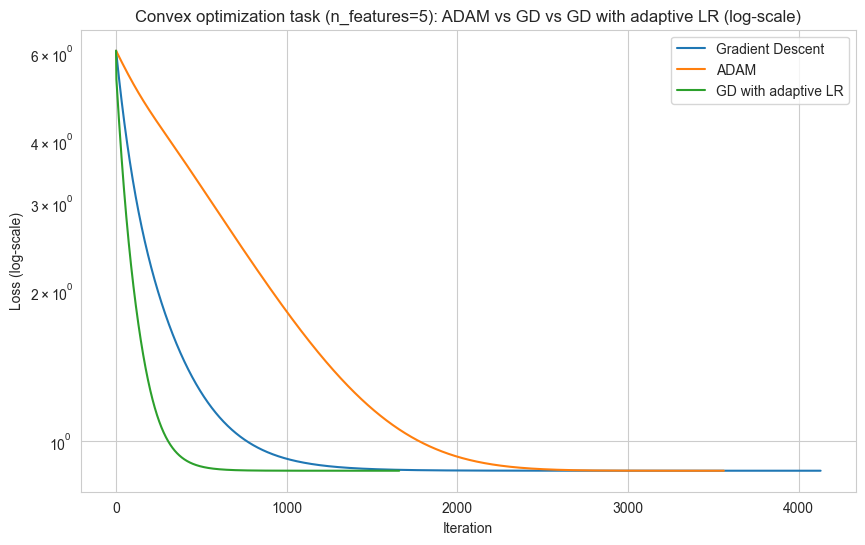

,Name,Iteration count,Loss
0,Gradient Descent,4129,0.871401
1,ADAM,3562,0.871401
2,GD with adaptive LR,1660,0.871401


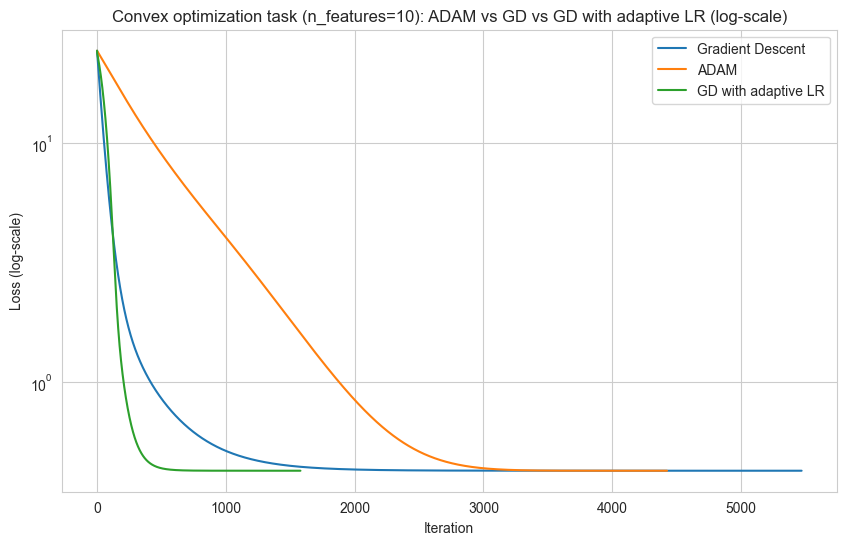

,Name,Iteration count,Loss
0,Gradient Descent,5471,0.42492
1,ADAM,4426,0.42492
2,GD with adaptive LR,1580,0.42492


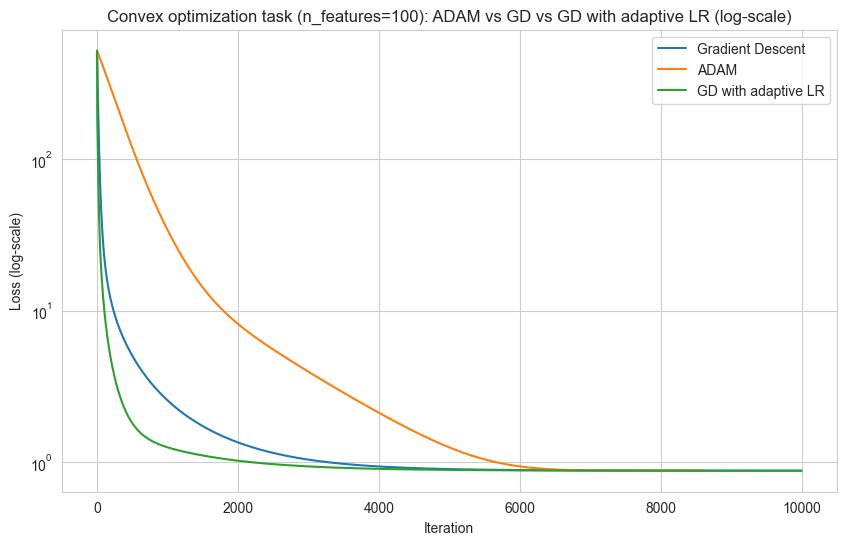

,Name,Iteration count,Loss
0,Gradient Descent,10001,0.874342
1,ADAM,8638,0.874116
2,GD with adaptive LR,9999,0.874317


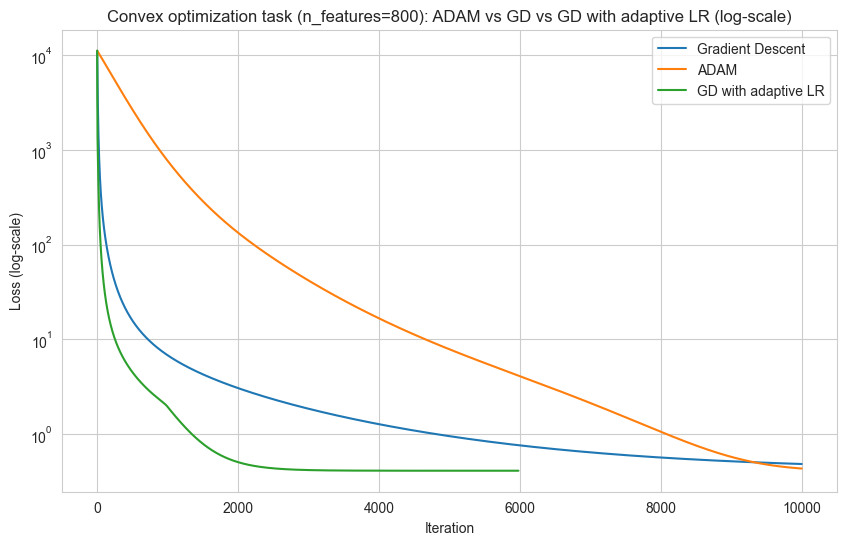

,Name,Iteration count,Loss
0,Gradient Descent,10001,0.483484
1,ADAM,10001,0.433049
2,GD with adaptive LR,5980,0.410628


In [2]:
for dim in available_dims:
    stats = f"../models/{dim}d_convex_optimization_vec_normalize_stats.pkl"
    model = f"../models/{dim}d_convex_optimization"

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result = exps.optimize_exp(env_config, model_dir)
    
    exps.plot_converging_comparasion(result, dim)
    display(exps.plot_comparasion_table(result))
    

Now lets look at the distribution of the number of iterations for the algorithm

In [4]:
sample_count = 10

for dim in available_dims:
    print(f"Distribution of iterations number on {dim}-dim convex problem")

    stats = f"../models/{dim}d_convex_optimization_vec_normalize_stats.pkl"
    model = f"../models/{dim}d_convex_optimization"

    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    stats = exps.plot_iterations_distribution(sample_count, env_config, model_dir)

    display(stats)

Distribution of iterations number on 5-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,4387.1,217228.69,466.08,3781.0,5152.0,1371.0
ADAM,3067.9,870233.29,932.86,1446.0,4229.0,2783.0
GD with adaptive LR,1767.2,56167.36,237.00,1468.0,2150.0,682.0


Distribution of iterations number on 10-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,5604.8,433593.16,658.48,4733.0,6829.0,2096.0
ADAM,4093.0,599047.00,773.98,2830.0,5091.0,2261.0
GD with adaptive LR,1901.0,337181.20,580.67,1275.0,3195.0,1920.0


Distribution of iterations number on 100-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,10001.0,0.0,0.00,10001.0,10001.0,0.0
ADAM,8073.0,172827.0,415.72,7303.0,8796.0,1493.0
GD with adaptive LR,9999.0,0.0,0.00,9999.0,9999.0,0.0


Distribution of iterations number on 800-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,10001.0,0.00,0.0,10001.0,10001.0,0.0
ADAM,10001.0,0.00,0.0,10001.0,10001.0,0.0
GD with adaptive LR,5842.5,8760.65,93.6,5694.0,6024.0,330.0
